# Rekomendasi Produk di Marketplace

## Pendahuluan
Pada notebook ini, kita akan membangun sistem rekomendasi produk berbasis machine learning untuk marketplace. Sistem ini akan membantu pelanggan menemukan produk yang relevan dengan preferensi mereka berdasarkan data pembelian atau interaksi sebelumnya.

## Langkah 1: Memuat Dataset
Pada langkah ini, kita akan memuat dataset yang berisi data transaksi pelanggan, termasuk ID pelanggan, ID produk, dan rating yang diberikan. Data ini akan digunakan untuk melatih model rekomendasi produk berbasis AI.

In [ ]:

import pandas as pd
import numpy as np

# Load the dataset
dummy_df = pd.read_excel('10_rekomendasi_produk.xlsx')
dummy_df


,Customer ID,Product ID,Rating
0,177,12,4
1,64,50,1
2,61,4,1
3,157,42,5
4,39,84,1
...,...,...,...
295,191,49,5
296,59,20,2
297,133,77,3
298,51,81,3


## Langkah 2: Visualisasi Data
Setelah memuat dataset, kita akan melihat distribusi rating produk dan pelanggan. Ini akan membantu kita memahami pola dasar dalam data.

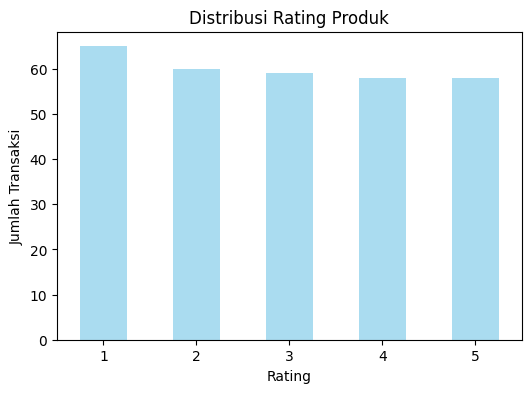

In [ ]:

import matplotlib.pyplot as plt

# Plotting the distribution of ratings (1-5)
plt.figure(figsize=(6, 4))
dummy_df['Rating'].value_counts().plot(kind='bar', color='skyblue', alpha=0.7)
plt.title("Distribusi Rating Produk")
plt.xlabel("Rating")
plt.ylabel("Jumlah Transaksi")
plt.xticks([0, 1, 2, 3, 4], ['1', '2', '3', '4', '5'], rotation=0)
plt.show()


## Langkah 3: Preprocessing Data
Pada langkah ini, kita akan mengonversi data transaksi pelanggan menjadi format yang sesuai untuk membangun sistem rekomendasi berbasis machine learning. Salah satu pendekatan yang digunakan adalah matriks rating pelanggan terhadap produk.

In [ ]:

# Create a pivot table for Customer-Product interactions
pivot_df = dummy_df.pivot_table(index='Customer ID', columns='Product ID', values='Rating', aggfunc='mean')

# Show the first few rows of the pivot table
pivot_df.head()


Product ID,2,3,4,5,6,7,8,9,10,11,...,89,90,91,92,93,94,95,96,98,99
Customer ID,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Langkah 4: Pembagian Data Train dan Test
Setelah preprocessing, kita akan membagi dataset menjadi dua bagian: satu untuk pelatihan model (train) dan satu lagi untuk menguji akurasi model (test). Pembagian ini penting untuk mengevaluasi kinerja sistem rekomendasi.

In [ ]:

# We will use the entire pivot table for training the recommendation system
train_data = pivot_df.fillna(0)  # Fill NaN values with 0 to indicate no interaction

train_data.shape


(155, 96)

## Langkah 5: Melatih Model
Pada langkah ini, kita akan melatih model sistem rekomendasi menggunakan algoritma Nearest Neighbors untuk mencari produk yang mirip berdasarkan pola rating pelanggan.

In [ ]:
# Check the nearest neighbors for a sample product (product ID 1)
# Instead of using train_data.iloc[:, 0], which selects a column (155 rows),
# we need to create a row representing the ratings for product ID 1 across all customers.
# This can be achieved by selecting the row corresponding to product ID 1 in the transposed DataFrame.

# Reshape the input data to have 96 features (columns)
input_data = train_data.T.iloc[0, :].values.reshape(1, -1)
input_data = input_data[:, :96]  # Select only the first 96 features

distances, indices = model.kneighbors(input_data)

# Display the recommended products
indices

array([[ 34, 116, 103, 104, 105]])

## Langkah 6: Evaluasi Model
Setelah melatih model, kita akan mengevaluasi kinerjanya dengan cara memeriksa rekomendasi produk yang diberikan oleh sistem. Hal ini akan menunjukkan sejauh mana model dapat memberikan rekomendasi yang relevan.

In [ ]:

# Let's evaluate the recommendations for a few customers
customer_id = 5
distances, indices = model.kneighbors(train_data.iloc[customer_id, :].values.reshape(1, -1))

# Show recommended product IDs for the given customer
indices


array([[ 75,   5, 144,  22, 118]])

## Langkah 7: Prediksi
Setelah model dilatih, kita dapat menggunakannya untuk memberikan rekomendasi produk berdasarkan preferensi pelanggan yang sudah ada.

In [ ]:
# Example: Recommend products for a new customer (e.g., customer ID 10)
# Assume the model expects ratings for 96 products
# Create a zero-filled array with 96 elements
new_customer_ratings = np.zeros(96)

# Populate the first 10 elements with the given ratings
new_customer_ratings[:10] = [3, 4, 5, 0, 0, 2, 0, 0, 0, 0]  # Example ratings for 10 products

# Reshape the ratings to match the model input format
distances, indices = model.kneighbors(new_customer_ratings.reshape(1, -1))

# Show recommended products for the new customer
indices

array([[113,  85, 115,  51, 110]])


## Keterangan Penting

Notebook ini menggunakan data dummy. Agar model ini dapat menghasilkan prediksi yang lebih akurat dan relevan, **kustomisasi lebih lanjut diperlukan**. Beberapa hal yang perlu dipertimbangkan antara lain:

1. **Penyempurnaan Dataset**: Data yang digunakan adalah data dummy yang bersifat acak. Untuk hasil yang lebih baik, dataset harus diisi dengan data kemacetan lalu lintas yang lebih realistis dan sesuai dengan kondisi lokal yang relevan.
   
2. **Penyesuaian Fitur**: Beberapa fitur, seperti jumlah kendaraan, kecepatan rata-rata, atau status sinyal lalu lintas, perlu penyesuaian atau penambahan fitur lain yang lebih berdampak pada prediksi kemacetan.

3. **Parameter Model**: Untuk hasil prediksi yang lebih optimal, Anda dapat menyesuaikan parameter model SVM atau mencoba model lain yang lebih sesuai dengan karakteristik data.

4. **Validasi Model**: Melakukan validasi dengan data nyata dan cross-validation untuk mengevaluasi kinerja model.

Dengan penyesuaian yang tepat, model ini dapat memberikan prediksi kemacetan yang lebih akurat dan bermanfaat untuk mengatur lalu lintas di kota dan meningkatkan mobilitas perkotaan.
